Arbol entrenado
prestamo :  aprobado


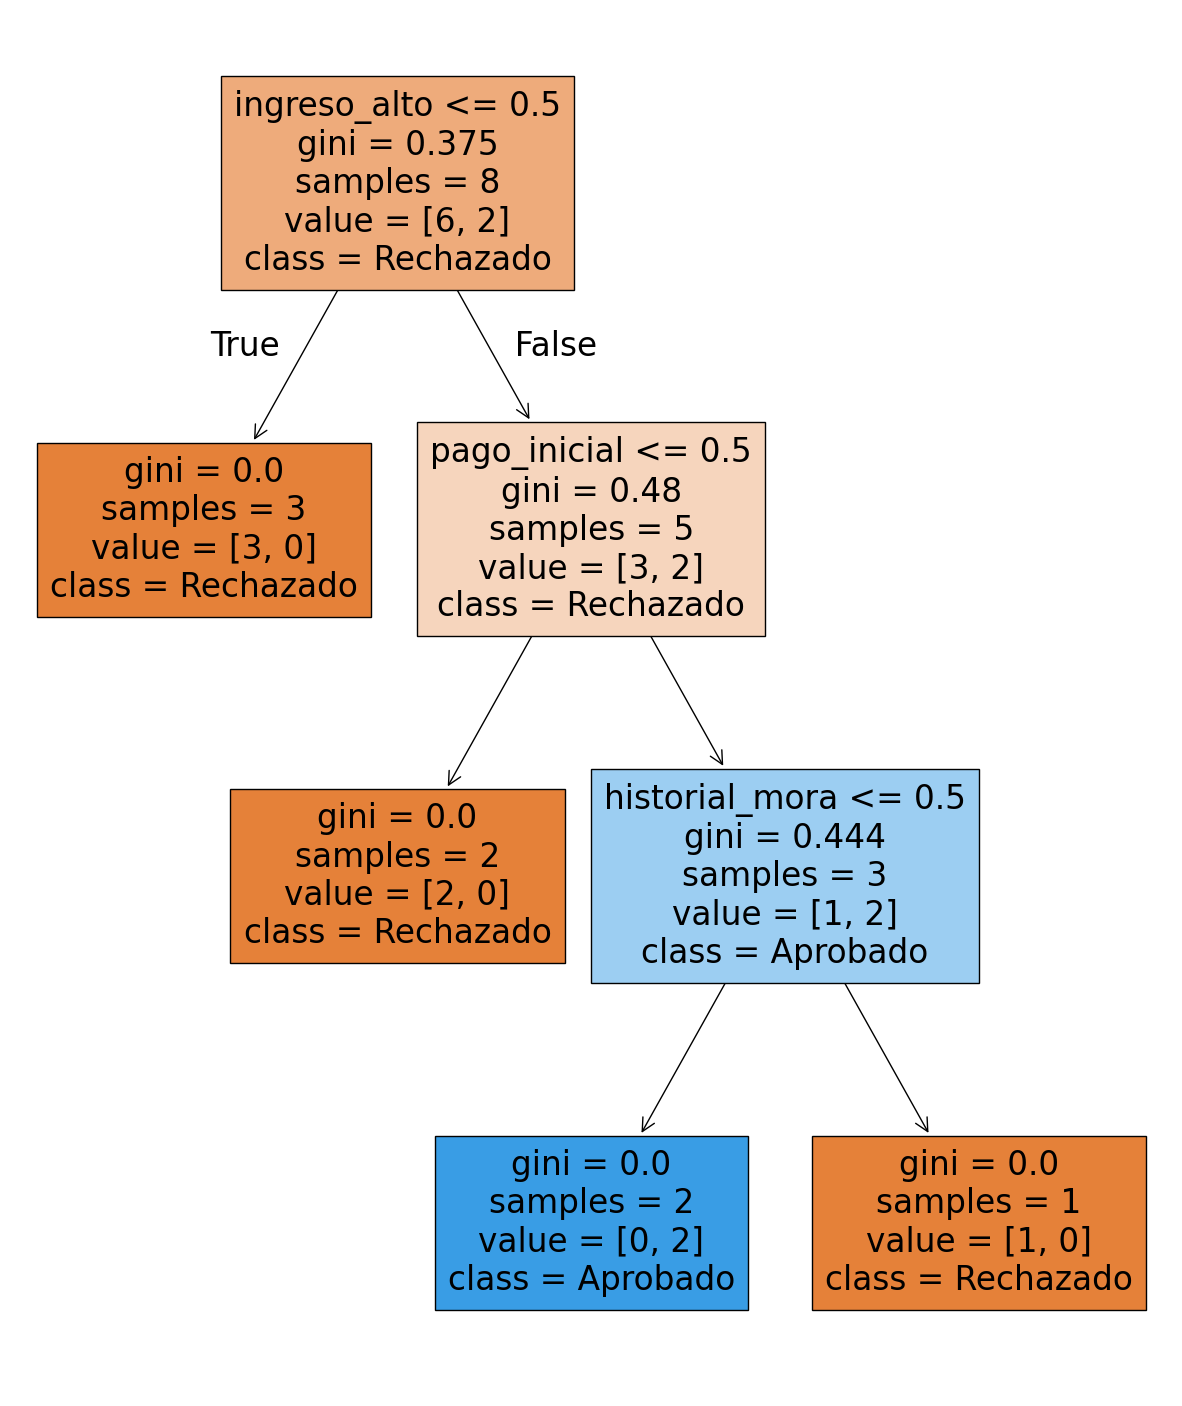

In [ ]:
import pandas as pd                                               #pandas: para crear y manejar datos(Dataframes)
import numpy as np                                                #numpy: para tranajar con numeros y valores especiales
import matplotlib.pyplot as plt                                   #matplotlib: para dinujar el arbol de decision

from sklearn.linear_model import LinearRegression                 #modelo de regresion lineal
from sklearn.tree import DecisionTreeClassifier, plot_tree        #arbol de decision + funcion para dibujarlo

#crear la tabla con 8 solicitudes de prestamo ya resueltas

prestamos = pd.DataFrame({
    "pago_inicial":[1,0,1,1,0,1,0,1],                            #1= si entrego el pago inicial, 0=no entrego
    "ingreso_alto":[1,1,0,1,0,1,1,0],                            #1= ingreso mensual mayor a 1000, 0=no
    "historial_mora":[0,0,0,1,1,0,0,1],                          #1=tiene historial de mora, 0=no tiene
    "aprobado":[1,0,0,0,0,1,0,0]                                 #1=el prestamo fue aprobado, 0=fue rechazado
})

prestamos                                                        #mostramos la tabla para revisar los datos

#seperamos X(las pistas) e y (lo que queremos predecir)
X=prestamos[["pago_inicial","ingreso_alto","historial_mora"]]    #tres columnas de pistas
y=prestamos["aprobado"]                                          #la columna que queremos predecir


#Creamos el arbol de decision limitado a una profundidad de 3 preguntas

arbol=DecisionTreeClassifier(max_depth=3,random_state=42)         #random_state fija el resultado que siempre sea igual
arbol=arbol.fit(X,y)

print("Arbol entrenado")

#probamos el arbol con un cliente nuevo
cliente_nuevo=pd.DataFrame({"pago_inicial":[1],"ingreso_alto":[1],"historial_mora":[0]})
prediccion=arbol.predict(cliente_nuevo)                          #el arbol recorre sus preguntas y da una respuesta

resultado="aprobado" if prediccion[0]==1 else "rechazado"
print("prestamo : ",resultado)

plt.figure(figsize=(15, 18))                      # definimos el tamaño de la imagen
plot_tree(
    arbol,                                        # el árbol ya entrenado
    feature_names=X.columns,                      # nombres de las columnas de X, para las etiquetas
    class_names=["Rechazado", "Aprobado"],        # nombres de las dos categorías posibles de y
    filled=True,                                  # colorea cada caja según la categoría que predice
)
plt.show()                                        # muestra el dibujo en pantalla

Seleccione el archivo de clientes a usar:


Saving clientes_nuevos.xlsx to clientes_nuevos (6).xlsx
     pago_inicial  ingreso_alto  historial_mora  aprobado
0               0             0               1         0
1               1             1               1         0
2               0             0               0         0
3               0             0               0         0
4               0             1               1         1
..            ...           ...             ...       ...
195             1             1               1         1
196             1             1               0         1
197             1             1               0         1
198             0             1               1         0
199             0             0               1         0

[200 rows x 4 columns]

Arbol entrenado 
El prestamo al cliente nuevo fue aprobado


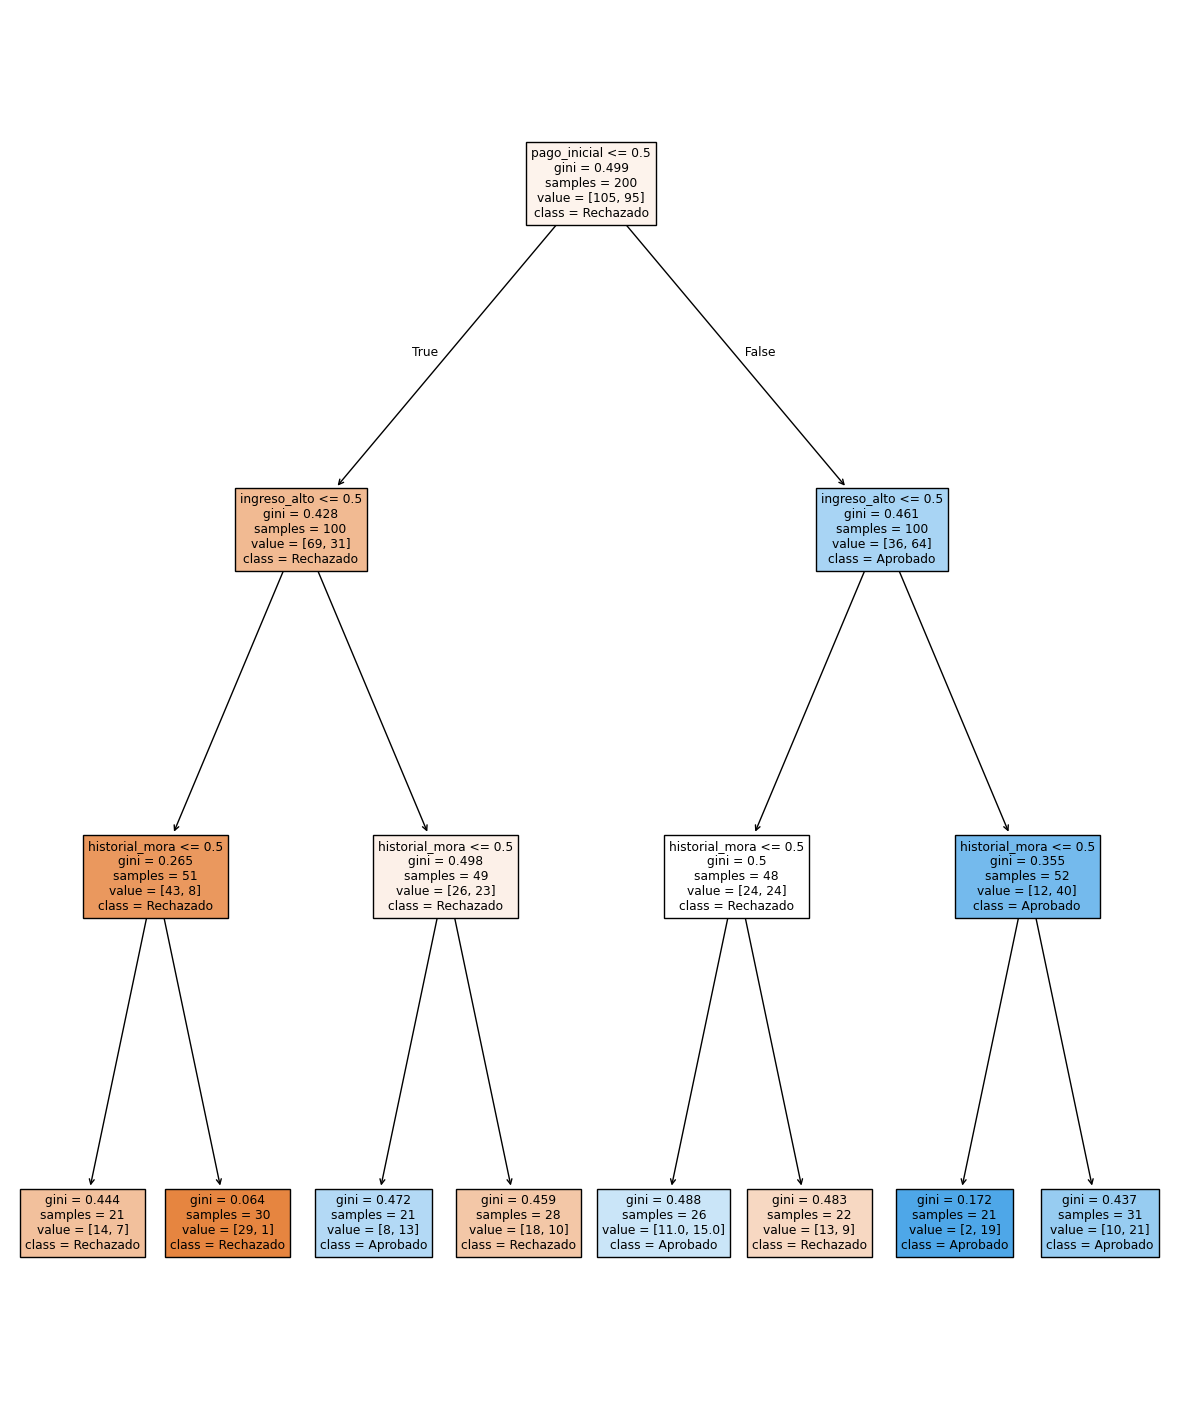

In [ ]:
from google.colab import files
import pandas as pd # Para crear y manejar tablas
import numpy as np # para trabajar con números y valores especiales
import matplotlib.pyplot as plt # para dibujar el árbol de decisión

from sklearn.linear_model import LinearRegression # modelo de regresión lineal
from sklearn.tree import DecisionTreeClassifier as dtc, plot_tree # árbol de decisión + función para dibujarlo

print("Seleccione el archivo de clientes a usar:")
subido = files.upload()
nombre_archivo = list(subido.keys())[0] if len(subido) > 0 else None
prestamos = pd.read_excel(nombre_archivo, sheet_name=0) if nombre_archivo else None

# Crear la tabla con 8 solicitudes de prestamo de muestra si no se carga el archivo
prestamos = pd.DataFrame({
    "pago_inicial":   [1,0,1,1,0,1,0,1], # 1 = Si entrego pago inicial
    "ingreso_alto":   [1,1,0,1,0,1,1,0], # 1 = Ingresuo mensual mayor a $1000
    "historial_mora": [0,0,0,1,1,0,0,1], # 1 = Tiene historial de mora
    "aprobado":       [1,0,0,0,0,1,0,0]  # El prestamo fue aprobado
}) if prestamos is None else prestamos

# Gráfico de dispersión

print(prestamos)

# Separamos X (las pistas) e y (lo que queremos predecir)
X = prestamos[["pago_inicial", "ingreso_alto", "historial_mora"]] # Tres columnas de pistas
y = prestamos["aprobado"] # La columna que queremos predecir

# Creamos el arbol de decisión limitado a una profundidad de 3 preguntas
arbol = dtc(max_depth=3, random_state=42)

# Entrenamos el arbol de decisión
arbol.fit(X,y)

#Imprimir arbol
print(f"\nArbol entrenado {'con datos de prueba' if not nombre_archivo else ''}")

# Probamos el árbol con un cliente nuevo
#pago_inicial = input("Realizo pago inicial? (S/N)")
#ingreso_alto = input("Cuenta con ingreso alto (S/N)")
#historial_mora = input("Tiene historial de mora? (S/N)")

cliente_nuevo = pd.DataFrame({"pago_inicial":[1], "ingreso_alto":[1], "historial_mora":[0]})
prediccion = arbol.predict(cliente_nuevo)

print(f"El prestamo al cliente nuevo {'no ' if prediccion[0] == 0 else ''}fue aprobado")

plt.figure(figsize=(15, 18))                      # definimos el tamaño de la imagen
plot_tree(
    arbol,                                        # el árbol ya entrenado
    feature_names=X.columns,                      # nombres de las columnas de X, para las etiquetas
    class_names=["Rechazado", "Aprobado"],        # nombres de las dos categorías posibles de y
    filled=True,                                  # colorea cada caja según la categoría que predice
)
plt.show()                                        # muestra el dibujo en pantalla

In [ ]:
#Crear la tabla de clientes, ya con problemas tipicos
clientes = pd.DataFrame({
    "id":      [1, 2, 3, 4, 5],                  # identificador de cada cliente
    "edad":    [25, 34, np.nan, 25, 300],        # np.nan = valor faltante; 300 = valor imposible
    "ingreso": [450000, 520000, 610000, 450000, 700000], # ingreso mensual de cada cliente
})

clientes #mostrar la tabla, el cliente tiene 3 "Nan" t el cliente 4 es igual al cliente 1

#paso 1: detectar cuantos valores faltantes hay por columna
clientes.isna().sum() # isna() marca True donda hay un valor nulo, .sum() los cuenta por columna

#paso 2 : una edad de 300 años tambien es un dato faltante (es un erro, no un valor real)
clientes.loc[clientes["edad"]>100] = np.nan #.loc selecciona filas con edad > 100 y las marca como NaN
clientes #ahora hay dos filas con NaN: la que ya faltaba y la que era imposible

#paso 3: calcular la mediana usando solo las edades qque si son validas
mediana_edad=clientes["edad"].median() #la mediana es un valor tipico, poco afectado por outliers
print(f"Mediana de edad (calculada sin los valores faltantes): {mediana_edad}")

#paso 4: Rellenar ambos NaN (el faltante original)
clientes["edad"]=clientes["edad"].fillna(mediana_edad) #reemplaza los NaN por la mediana
clientes

#paso 5: eliminar la fila diplicada (misma edad e ingresi eb itra fila)
clientes=clientes.drop_duplicates(subset=["edad","ingreso"],keep="first") #conserva solo la primera aparacion

clientes #tabla final: sin nulos, sin valores imposibles y sin filas duplicadas


Mediana de edad (calculada sin los valores faltantes): 25.0


,id,edad,ingreso
0,1.0,25.0,450000.0
1,2.0,34.0,520000.0
2,3.0,25.0,610000.0
4,NaN,25.0,NaN
